<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_1_SLR/17.1.1_SLR_From_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression from Scratch
Author: Brad Sheese
---
NOTE: If you want to save your work select the following from the menu above:**File  --> Save a copy in Drive**If you work on the copy you made all changes will be saved to Google Drive. If you do not save your own copy, you can work in 'playground mode' instead, and any changes you make will be lost after you're done.


In [2]:
# imports
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random


## Borrowed from the Previous Reading:

The (Made Up) Correlation Between Sugar and Sweet


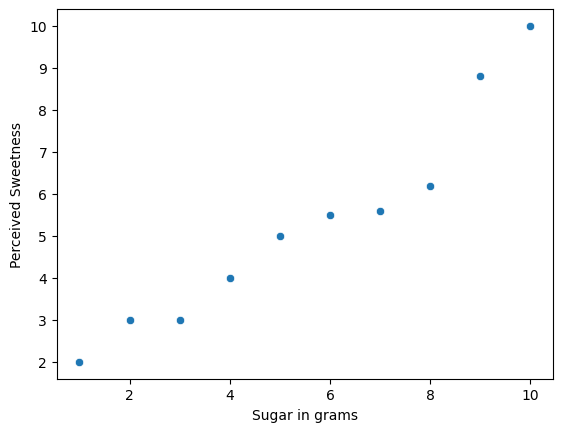

,sugar,sweet
sugar,1.00000,0.96347
sweet,0.96347,1.00000


In [3]:
# make our data
sugar = np.array([1,2,3,4,5,6,7,8,9,10])
sweet = np.array([2,3,3,4,5,5.5,5.6,6.2,8.8,10])
studydata = pd.DataFrame(zip(sugar,sweet), columns = ['sugar','sweet'])

# plot our data
sns.scatterplot(x = 'sugar', y = 'sweet', data = studydata)
plt.xlabel('Sugar in grams')
plt.ylabel('Perceived Sweetness')
plt.show()

# calculate correlation, Pearson's R
studydata.corr()


A simple linear regression with the same data.


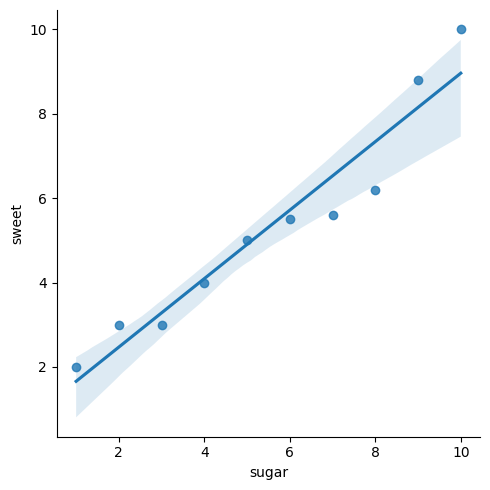

In [4]:
sns.lmplot(x='sugar', y='sweet', data=studydata)
plt.show()


## Writing Our Own Simple Linear Regression FunctionOur goal is to write a function that creates a simple linear regression model. Our function should take two arrays of equal length. One should be the feature and the other is the outcome. Notably, in the sciences these are almost always referred to as the indendent variable(s) and the dependent variable. But students have a remarkably hard time remembering which is which when we use those terms, so we will stick with our coding rule to use informative variable names and adopt 'feature' and 'outcome' for now.

We want to build a model that eventually will look like this:```# here's the model we want to buildoutcome = intercept + (slope * predictor)# here's the same model using terms common in the sciencesdependent_variable = intercept + (slope * independent_variable)# the same model using terms common in machine learningoutcome = bias + (scale_factor * feature)# the same model using terms common in statisticsY = B0 + (B1 * x)```Before we start into the code, think a bit about what this function can do for you. If you have the slope and intercept of the model, you can plug in any value for the predictor and get back a value for the outcome. Do that over and over again and plot all of the predictor and outcome pairs and you get a line.

That line is a graphical representation of the simple linear model we have built from our data.


## Problem 1: my_prediction() Let's start by writing a function called `my_prediction()` that takes three arguments: `slope`, `intercept`, `feature_value` and returns the predicted outcome value.

To do this, look at the formulas presented above and 'translate' them using the variable names we have provided.


In [5]:
def my_prediction(slope, intercept, feature_value):
  return intercept + slope * feature_value


In [6]:
#@title Run to test your my_prediction() function
function_error_message = 'Something went wrong with your function.'
try:
  if (my_prediction(1,1,1) == 2 and
      my_prediction(10,11,12) == 131 and
      my_prediction(0,-1,-100) == -1):
    print('Your function worked!')
  else:
    print(function_error_message)
except:
  print(function_error_message)


Your function worked!


## Finding the Slope and Intercept with OLS

Okay, now we just need to find the slope and the intercept to feed into our my_prediction() function.### Line of Best FitWe want to determine the line (slope and intercept) that best represents the relationship in our data. "Best fit" typically refers to the line that is as close as possible to all observed data points.

In the context of Ordinary Least Squares (OL

S) regression, this means finding the line that minimizes the sum of the squared errors -- the squared distances between each actual data point and the corresponding point on the regression line.### ResidualsEach data point has a **residual**, which is the vertical distance from the observed point to the regression line:$$e_i = y_i - \hat{y}_i$$Where:- $y_i$ is the **observed** outcome value- $\hat{y}_i$ is the **predicted** outcome value (the point on the regression line) You can think of this as a decomposition:$$\text{Data} = \text{Fit} + \text{Residual}$$- If the residual is **positive**, the model **underpredicted** (the actual value was above the line)- If the residual is **negative**, the model **overpredicted** (the actual value was below the line)- 

A good model has residuals that are as small as possible### Why Minimize *Squared* Residuals? We could try to find the best line by minimizing the sum of the absolute residuals: $|e_1| + |e_2| + \dots + |e_n|$. This actually produces a reasonable line! But the more common approach is to minimize the sum of **squared** residuals: $e_1^2 + e_2^2 + \dots + e_n^2$. Here's why:1. **Larger errors are penalized more heavily**: Being off by 4 is usually *more than* twice as bad as being off by 2. Squaring accounts for this.2. **Mathematical convenience**: The least squares solution has a clean closed-form formula (which we're about to implement by hand).3. **Statistical inference**: The methods for making population-level claims from sample data are most straightforward when using least squares.4. **Convention**: It's the most widely used method and is supported everywhere.

The line that minimizes the sum of squared residuals is called the **least squares line**.### Approaches for Finding the Line of Best FitRegression is considered a form of machine learning because the model learns to fit the line to the data. There are different algorithms it can use to do this. For simple linear regression, we can use the [ordinary least squares (OLS)](https://en.wikipedia.org/wiki/Ordinary_least_squares) method, which is similar to how we calculated variance in a previous exercise.

For more complex models, we will use a different approach called gradient descent, which we will see is also used in other machine learning tools.


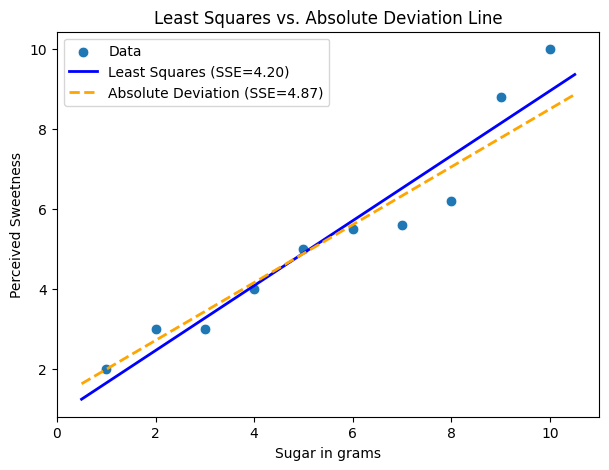

Least Squares:      SSE = 4.20,  Sum of |residuals| = 5.31
Absolute Deviation: SSE = 4.87,  Sum of |residuals| = 5.22

Notice: the absolute deviation line has a smaller sum of |residuals|,
but the least squares line has a smaller SSE. Each method optimizes
for a different criterion.


In [7]:
# Visual comparison: least squares line vs. absolute deviation line
from scipy.optimize import minimize

# OLS line
from sklearn.linear_model import LinearRegression
X_sk = studydata['sugar'].values.reshape(-1, 1)
y_sk = studydata['sweet'].values
ols_model = LinearRegression().fit(X_sk, y_sk)
ols_slope = ols_model.coef_[0]
ols_intercept = ols_model.intercept_

# Absolute deviation line (minimize sum of |residuals|)
def abs_deviation(params):
    slope, intercept = params
    predicted = intercept + slope * studydata['sugar'].values
    return np.sum(np.abs(studydata['sweet'].values - predicted))

result = minimize(abs_deviation, x0=[0.8, 1.0])
abs_slope = result.x[0]
abs_intercept = result.x[1]

# Compute SSE for both
ols_predicted = ols_intercept + ols_slope * studydata['sugar'].values
abs_predicted = abs_intercept + abs_slope * studydata['sugar'].values

ols_sse = np.sum((studydata['sweet'].values - ols_predicted)**2)
abs_sse = np.sum((studydata['sweet'].values - abs_predicted)**2)

ols_sar = np.sum(np.abs(studydata['sweet'].values - ols_predicted))
abs_sar = np.sum(np.abs(studydata['sweet'].values - abs_predicted))

# Plot both lines
plt.figure(figsize=(7, 5))
sns.scatterplot(x='sugar', y='sweet', data=studydata, s=60, label='Data')
x_range = np.linspace(0.5, 10.5, 100)
plt.plot(x_range, ols_intercept + ols_slope * x_range,
         color='blue', linewidth=2, label=f'Least Squares (SSE={ols_sse:.2f})')
plt.plot(x_range, abs_intercept + abs_slope * x_range,
         color='orange', linewidth=2, linestyle='--',
         label=f'Absolute Deviation (SSE={abs_sse:.2f})')
plt.xlabel('Sugar in grams')
plt.ylabel('Perceived Sweetness')
plt.title('Least Squares vs. Absolute Deviation Line')
plt.legend()
plt.show()

print(f"Least Squares:      SSE = {ols_sse:.2f},  Sum of |residuals| = {ols_sar:.2f}")
print(f"Absolute Deviation: SSE = {abs_sse:.2f},  Sum of |residuals| = {abs_sar:.2f}")
print()
print("Notice: the absolute deviation line has a smaller sum of |residuals|,")
print("but the least squares line has a smaller SSE. Each method optimizes")
print("for a different criterion.")


## Problem 2: my_mean() Write a function called my_mean(). The function will take a single dataframe series as an argument and will return the mean of that series. When you are writing your function you may not use any pandas series methods.

You must take each value from the series one at a time and write a function that generates the proper statistic when you get through all of the values.


In [8]:
def my_mean(series):
  total = 0
  count = 0
  for val in series:
    total += val
    count += 1
  return total / count


In [9]:
#@title Run this block to test your function
try:
  if math.isclose(my_mean(studydata['sweet']), studydata['sweet'].mean()):
    print(function_success_message)
  else:
    print(function_error_message)
except:
  print(function_error_message)


Your function worked!


## Problem 3: my_distances() Write a function called my_distances() that finds the difference between all of the values in a series and the mean of that series, and returns all of those differences as an array. Use your `my_mean()` function in your `my_distances()` function. Note: when we wrote this function in a previous exercise, we used lists because we had not yet been introduced to arrays. Make sure you return an array here since we are going to be multiplying arrays in subsequent step, which is not something you can do with lists.

Use a list inside the function, append to it, and then convert the final list to an array.


In [10]:
def my_distances(series):
  series_mean = my_mean(series)
  distances_list = []
  for val in series:
    distance = val - series_mean
    distances_list.append(distance)
  return np.array(distances_list) # this will turn the list into an array


In [11]:
#@title Run this block test your function

array_comparison = (my_distances(studydata['sweet']) ==
                    my_distances_test(studydata['sweet']))

try:
  if array_comparison.all():
    print(function_success_message)
  else:
    print(function_error_message)
except:
  print(function_error_message)


Your function worked!


## An aside: X and y as variable names in machine learningWe are going to start using upper case `X` as a variable name to denote 'features' (a.k.a independent variables, a.k.a predictors). We are going to you use lower case `y` to denote the 'outcome' (a.k.a the dependent variable). If you've had some programming course work with us, you will hopefully recognize that these are poor choices for variable names. However, that's the convention in machine learning, so we are going to stick with it. Why?

This is just introductory material on machine learning, if you get into this area you will need to able to read and understand code written by others in this field and they will likely rely on these conventions.


## Problem 4: Means and distances`X` is going to be our feature, sugar in this example. `y` is going to be our outcome, perceived sweetness. We need to calculate the slope using our `my_mean()` and `my_distances()` functions.

Before we get into details of the equation, use the functions you wrote to create the following for X (sugar) and y (sweet):* `X_mean`* `

X_distances_array`* `y_mean`* `y_distances_array`


In [12]:
# enter and test your code here
X_mean = my_mean(studydata['sugar'])
X_distances_array = my_distances(studydata['sugar'])

y_mean = my_mean(studydata['sweet'])
y_distances_array = my_distances(studydata['sweet'])

print(f"X_mean = {X_mean}")
print(f"y_mean = {y_mean}")


X_mean = 5.5
y_mean = 5.3100000000000005


## Problem 5: Calculating the slopeWe now have an array containing the distances between each data point's X coordinate value and the X mean, and the same for the y coordinates. We need to multiply each X distance by each y distance. We can do this simply enough, by multiplying the two arrays together.

Create a new array called `combined_distances` by multiplying the distances for 

X (sugar) by the distances for y(sweet).


In [13]:
# enter and test your code here
combined_distances = X_distances_array * y_distances_array
print(f"First 3 combined distances: {combined_distances[:3]}")


First 3 combined distances: [14.895  8.085  5.775]


Now we want to sum all of the values in combined_distances. Do that, and assign the result to a variable called `summed_combined_distances`.


In [14]:
# enter and test your code here
summed_combined_distances = np.sum(combined_distances)
print(f"Summed combined distances: {summed_combined_distances:.4f}")


Summed combined distances: 66.9500


And finally, you want to square just the X distances and then sum them. Assign the result to `summed_squared_X_distances`.


In [15]:
# enter and test your code here
summed_squared_X_distances = np.sum(X_distances_array ** 2)
print(f"Summed squared X distances: {summed_squared_X_distances:.4f}")


Summed squared X distances: 82.5000


Now we can put these components together to calculate the slope. Make a variable called `slope` and assign it the result of `summed_combined_distances` divided by `summed_squared_X_distances`.


In [16]:
#enter and test your code here
slope = summed_combined_distances / summed_squared_X_distances
print(f"Slope: {slope:.4f}")


Slope: 0.8115


In [17]:
#@title Run this to check your slope calculation
from sklearn.linear_model import LinearRegression
X = studydata['sugar'].values.reshape(len(studydata['sugar']),1)
y = studydata['sweet'].values.reshape(len(studydata['sweet']),1)
regression = LinearRegression().fit(X,y)

try:
  if np.isclose(regression.coef_[0,0], slope):
    print('Your slope was caculated correctly.')
  else:
    print('There is something wrong with your slope calculation.')

except:
  print("Your code produced an error.")


Your slope was caculated correctly.


## Problem 6: Calculating the interceptOnce we've got the slope, the rest is easy.

Make a variable called `intercept` and assign it to the result of `y_mean` minus the `slope` multiplied by `

X_mean`.


In [18]:
# enter and test your code here
intercept = y_mean - slope * X_mean
print(f"Intercept: {intercept:.4f}")


Intercept: 0.8467


In [19]:
#@title Run this to check your intercept calculations
from sklearn.linear_model import LinearRegression
X = studydata['sugar'].values.reshape(len(studydata['sugar']),1)
y = studydata['sweet'].values.reshape(len(studydata['sweet']),1)
regression = LinearRegression().fit(X,y)

try:
  if np.isclose(regression.intercept_[0], intercept):
    print('Your intercept was calculated correctly')
  else:
    print('There is something wrong with your intercept calculation.')

except:
  print("Your code produced an error.")


Your intercept was calculated correctly


## Problem 7: Generating predicted y valuesSo now we have all of the components to produce a regression line. We can use our calculated slope and intercept, along with the original X values to produce the regression line, which you can think of as our predicted y values. The formula you want to use here is:```predicted_y_value = intercept + slope * x_value```Note:

An equivalent, and possibly more familiar version of the equation is:```y = mx + b```Write a function called `my_predicted_y()` that takes the slope, intercept, and 

X values as a series and returns an array of predicted y values.


In [20]:
def my_predicted_y(slope, intercept, series):
  predicted_y_list = []
  for x_val in series:
    predicted = intercept + slope * x_val
    predicted_y_list.append(predicted)
  return np.array(predicted_y_list)


## Problem 8: Plot your regression and scatterplotCreate a new variable called `predicted_y_values` and assign it the return of your `my_predicted_y()` using the slope, intercept and sugar values as arguments. Use `predicted_y_values` and the sugar values to plot a regression line. Use the sugar values and the sweet values to create a scatterplot. Plot them on the same figure.

To do this using 

Seaborn, you can first call `sns.scatterplot()`, then `sns.lineplot()`, then `plt.show()`, but you'll need to insert the appropriate arguments.


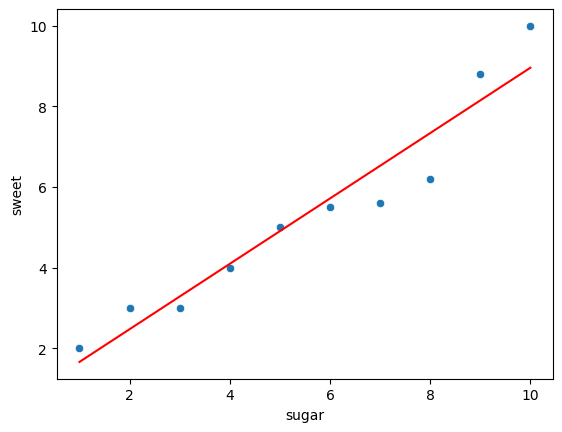

In [21]:
# complete the code below
predicted_y_values = my_predicted_y(slope, intercept, studydata['sugar'])

sns.scatterplot(x='sugar', y='sweet', data=studydata)
sns.lineplot(x=studydata['sugar'], y=predicted_y_values, color='red')
plt.show()


## Problem 8.5: Computing and Plotting ResidualsNow that we have predicted values, we can compute the **residuals** -- the difference between what we observed and what the model predicted:$$e_i = y_i - \hat{y}_i$$A **residual plot** shows these residuals on the y-axis against the predictor values on the x-axis. A horizontal reference line at 0 helps us see which points the model overpredicted (below the line, negative residuals) and underpredicted (above the line, positive residuals).

If the linear model is appropriatete, the residuals should look like random noise scattered around 0 with no clear pattern.**Task:** 

Compute the residuals and create a residual plot.


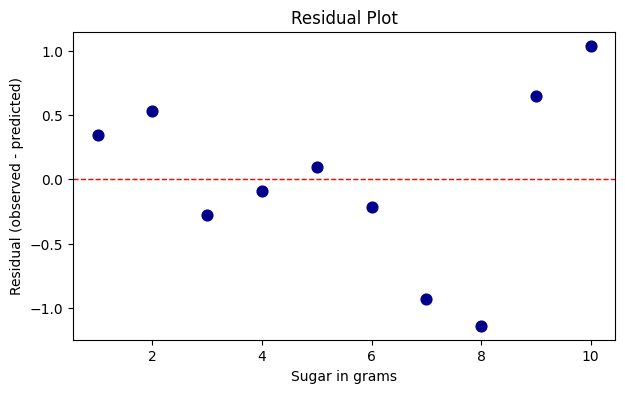

  sugar=1g,  sweet=2.0,  predicted=1.66,  residual=0.34
  sugar=2g,  sweet=3.0,  predicted=2.47,  residual=0.53
  sugar=3g,  sweet=3.0,  predicted=3.28,  residual=-0.28
  sugar=4g,  sweet=4.0,  predicted=4.09,  residual=-0.09
  sugar=5g,  sweet=5.0,  predicted=4.90,  residual=0.10
  sugar=6g,  sweet=5.5,  predicted=5.72,  residual=-0.22
  sugar=7g,  sweet=5.6,  predicted=6.53,  residual=-0.93
  sugar=8g,  sweet=6.2,  predicted=7.34,  residual=-1.14
  sugar=9g,  sweet=8.8,  predicted=8.15,  residual=0.65
  sugar=10g,  sweet=10.0,  predicted=8.96,  residual=1.04

Do the residuals show any pattern, or do they look randomly scattered around 0?
Random scatter suggests the linear model is appropriate.


In [22]:
# Compute residuals
residuals = studydata['sweet'].values - predicted_y_values

# Create residual plot
plt.figure(figsize=(7, 4))
plt.scatter(studydata['sugar'], residuals, s=60, color='darkblue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Sugar in grams')
plt.ylabel('Residual (observed - predicted)')
plt.title('Residual Plot')
plt.show()

# Print the residuals
for i in range(len(studydata)):
    print(f"  sugar={studydata['sugar'].iloc[i]:.0f}g,  sweet={studydata['sweet'].iloc[i]:.1f},  predicted={predicted_y_values[i]:.2f},  residual={residuals[i]:.2f}")

print()
print("Do the residuals show any pattern, or do they look randomly scattered around 0?")
print("Random scatter suggests the linear model is appropriate.")


## Problem 8.6: Computing R-squared from ScratchNow let's quantify how well our model explains the variation in the data. We'll compute **R-squared** ($R^2$), also called the **coefficient of determination**. R-squared measures the **proportion of variation in the outcome that is explained by the model**. It ranges from 0 to 1, where higher values mean the model explains more of the variation. To compute R-squared, we need two quantities:**Total Sum of Squares (SST)**: measures the total variability in the outcome around its mean.$$SST = \sum_{i=1}^{n} (y_i - \bar{y})^2$$**Sum of Squared Errors (SSE)**: measures the leftover variability after the model -- the sum of squared residuals.$$SSE = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \sum_{i=1}^{n} e_i^2$$**R-squared** is then:$$R^2 = \frac{SST - SSE}{SST} = 1 - \frac{SSE}{SST}$$**Task:** Compute SST,

SSE, and 

R-squared using your residuals and the y values.

**Regression Sum of Squares (SSR):** The variability explained by the model, calculated as $SSR = SST - SSE$. Together these form the fundamental identity:

$$SST = SSR + SSE$$

This tells us that the total variation in the outcome splits into what the model explains (SSR) plus what it doesn't (SSE). A good model has a large SSR relative to SSE.


In [23]:
# Compute SST: sum of (y_i - y_mean)^2
SST = np.sum((studydata['sweet'].values - y_mean) ** 2)

# Compute SSE: sum of squared residuals
SSE = np.sum(residuals ** 2)

# Compute R^2
R_squared = 1 - SSE / SST

print(f"SST (total variability in sweet):     {SST:.2f}")
print(f"SSE (leftover variability after model): {SSE:.2f}")
print(f"R-squared (proportion of variance explained):  {R_squared:.4f}")
print()

# Verify: R^2 should equal r^2 for simple linear regression
r = studydata['sugar'].corr(studydata['sweet'])
print(f"Verification: r = {r:.4f}, r^2 = {r**2:.4f}")
print(f"Our R-squared = {R_squared:.4f}")
print(f"Match: {np.isclose(R_squared, r**2)}")
print()
print(f"Interpretation: {R_squared*100:.1f}% of the variation in perceived sweetness")
print(f"is explained by sugar content in our linear model.")


SST (total variability in sweet):     58.53
SSE (leftover variability after model): 4.20
R-squared (proportion of variance explained):  0.9283

Verification: r = 0.9635, r^2 = 0.9283
Our R-squared = 0.9283
Match: True

Interpretation: 92.8% of the variation in perceived sweetness
is explained by sugar content in our linear model.


## Problem 9: Make a PredictionOnce we have developed a regression model based on the data we have we can use it to make predictions about data points we don't have. If the phenomena we are investigating really do exhibit a linear relationship across the range of values we are interested in the, a simple linear regression model can help us make a reasonable prediction. In our sugar/sweet study, we only studied sugar doses up to 10g. We would now like to use our model to make a prediction about perceived sweetness at 20g.

We can do this using the same model we just used:```predicted_y_value = intercept + slope * x_value```

Find the predicted sweetness for 20g of sugar and assign it to the variable `predicted_sweet_20g`.


In [24]:
# enter and test your code here

predicted_sweet_20g = intercept + slope * 20

print(f"Predicted sweetness at 20g sugar: {predicted_sweet_20g:.2f}")


Predicted sweetness at 20g sugar: 17.08


### A Warning 

About
 ExtrapolationThe prediction you just made is an example of **extrapolation** -- applying the model to a value of $x$ (20g) that is **outside the range of the observed data** (1-10g). Extrapolation is risky because the linear relationship we observed between 1g and 10g may not hold at higher doses. In fact, we noted at the beginning that the real relationship between sugar and sweetness follows the [Weber-Fechner law](https://en.wikipedia.org/wiki/Weber%E2%80%93Fechner_law), which is **not linear** -- sweetness perception eventually plateaus and may even decrease at very high concentrations.**General rule:** Be cautious about predictions outside the observed range of $x$. The further you extrapolate, the less reliable your prediction becomes.


### Problem 10: Putting it All TogetherWrite a function called `my_linear_regression()` that takes all of the following arguments:* feature (a series)* outcome (a series)* x value for making predictions (an integer or float) The function should calculate and report the slope and intercept for the model, compute and report R-squared, and also calculate and report the predicted y value for the given x value. This function may call the `my_mean()` and `my_distances()` functions.

Finally, the function should produce a single plot that provides a scatter plot of the provided series and a plotted regression line.

**In the next notebook (17.1.2)**, you will learn how to use the professional `scikit-learn` library to perform these same calculations with significantly less code.

**Looking Ahead:** In upcoming notebooks you'll learn about **outliers**, **leverage points**, and **influential points** -- observations that can disproportionately affect the least squares line you just computed. You'll also learn how to include **indicator variables** to model categorical predictors.

You'll also learn to identify **high leverage** points (observations with extreme predictor values) and **influential points** (leverage points that change the model's slope).


Slope: 0.8115
Intercept: 0.8467
R-squared: 0.9283
Predicted outcome at x=20: 17.0770


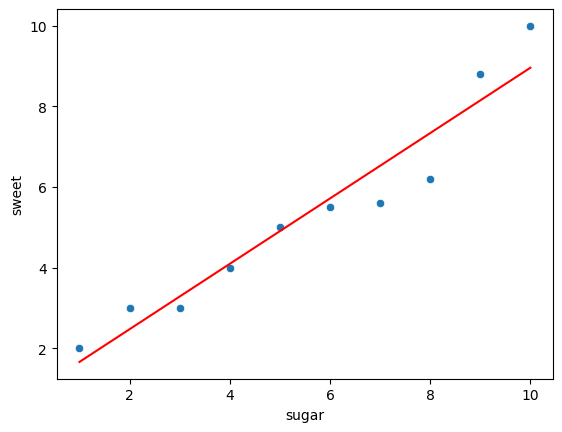

In [25]:
def my_linear_regression(feature, outcome, x_value):
  X_mean = my_mean(feature)
  y_mean = my_mean(outcome)

  X_distances_array = my_distances(feature)
  y_distances_array = my_distances(outcome)

  combined_distances = X_distances_array * y_distances_array
  summed_combined_distances = np.sum(combined_distances)
  summed_squared_X_distances = np.sum(X_distances_array ** 2)

  slope = summed_combined_distances / summed_squared_X_distances
  intercept = y_mean - slope * X_mean

  predicted_y_values = my_predicted_y(slope, intercept, feature)

  # Compute and print R^2
  SST = np.sum((outcome.values - y_mean) ** 2)
  SSE = np.sum((outcome.values - predicted_y_values) ** 2)
  R_squared = 1 - SSE / SST

  # Make prediction
  predicted_y = intercept + slope * x_value

  print("Slope: {:.4f}".format(slope))
  print("Intercept: {:.4f}".format(intercept))
  print("R-squared: {:.4f}".format(R_squared))
  print("Predicted outcome at x={}: {:.4f}".format(x_value, predicted_y))

  # Plot
  sns.scatterplot(x=feature, y=outcome)
  sns.lineplot(x=feature, y=predicted_y_values, color='red')
  plt.show()

my_linear_regression(studydata['sugar'],studydata['sweet'], 20)
